### Causal inference.
This notebook guides the user through the following steps: 
- causal inference for the tropical middle stratospheric ozone variability from observations and the TOMCAT CTM simulation (Fig.4),
- associated sensitivity tests for observations (Fig. 5), 
- regime-oriented direct causal effects from observations and the TOMCAT CTM simulation (Fig. 6), and
- total causal effects from observations and the TOMCAT CTM simulation across different time lags (Fig. 7).

In [ ]:
# Imports
import numpy as np
%matplotlib inline   
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import matplotlib.pyplot as plt
import pandas as pd
import sys
from collections import defaultdict
from datetime import datetime
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr

# ======== LOAD HELPER FUNCTIONS=======================
sys.path.append('/path/to/the/helper_functions/')
from helper_functions import  process_dataset, detrending, align_and_dropna_same_rows, load_qbo_proxies, summarize_year_fraction, build_qbo_regime_masks_from_shear
from helper_functions_causality import lpcmci_sensitivity,position_of_nodes,fix_graph,calculate_wright_coeffs, convert_dict_to_val_matrix, temporal_evolution, plot_temporal_evolution

#### Brief settings for the analysis

In [2]:
# Settings 
start, end = "2004-01", "2021-12"
var_names = ["w*", "N$_2$O", "NO$_2$", "O$_3$"]

# We further recommend one figure at a time. Execute code line by line. Do not skip any cells. 
Fig4 = True
Fig5 = False
Fig6 = False
Fig7 = False

if Fig6 and (Fig4 or Fig5):
    raise ValueError("To use Fig6, Fig4 and Fig5 must be False.")

if Fig4 or Fig5: 
    QBO_as_a_regime = False
elif Fig6 or Fig7: 
    QBO_as_a_regime = True
    
# use calculate_shear only when QBO_as_a_regime is True
if QBO_as_a_regime:
    calculate_shear = True
else: 
    calculate_shear = False
    
data_sources = ["OBS" , "TOMCAT"]

#### Load input data 

In [ ]:
# Provide the path for the preprocessed data
base_in = "/path/to/the/preprocessed/files/"

In [ ]:
files = {
    "TOMCAT": f"ctm741_data_collection_interpolated_{start[:4]}-{end[:4]}.nc",
    "OBS": f"obs_data_collection_interpolated_{start[:4]}-{end[:4]}.nc",
}

variable_mappings = {
    "TOMCAT": {
        "NO2_mm_anomaly": (r"NO$_2$", 1e9),
        "O3_mm_anomaly": (r"O$_3$", 1e6),
        "N2O_mm_anomaly": (r"N$_2$O", 1e9),
        "WSTAR_anomaly": (r"w*", 1000),
        "te_mm_anomaly": (r"T", 1),
    },
    "OBS": {
        "osiris_no2_anomaly": (r"NO$_2$", 1e9),
        "osiris_o3_anomaly": (r"O$_3$", 1e6),
        "mls_n2o_anomaly": (r"N$_2$O", 1e9),
        "era5_w_anomaly": (r"w*", 1000),
        "era5_ta_anomaly": (r"T", 1),
    },
}

df_dict = {}

for source in data_sources:
    df = process_dataset(base_in, files[source], variable_mappings[source])
    df = df[var_names].sort_index()
    df_dict[source] = df

# -------------------- choose which sets must be same length --------------------
# needed to take Nans into account and match all datasources
must_match_keys = ["OBS", "TOMCAT"]

df_dict, matched_keys, common_time_valid = align_and_dropna_same_rows(df_dict, must_match_keys)

print(
    f"Aligned & Nans are removed across: {matched_keys}\n"
    f"N={len(common_time_valid)}, {common_time_valid.min()} to {common_time_valid.max()}"
)

# Sanity checks
for k in matched_keys:
    print(k, len(df_dict[k]), df_dict[k].index.min(), df_dict[k].index.max())

assert all(df_dict[matched_keys[0]].index.equals(df_dict[k].index) for k in matched_keys[1:])


Aligned & Nans are removed across: ['OBS', 'TOMCAT']
N=199, 2004-08-01 00:00:00 to 2021-12-01 00:00:00
OBS 199 2004-08-01 00:00:00 2021-12-01 00:00:00
TOMCAT 199 2004-08-01 00:00:00 2021-12-01 00:00:00


In [4]:
# Lets check the missing dates
full_range = pd.date_range(start=start, end=end, freq='MS')
missing_dates = full_range.difference(df_dict['OBS']['O$_3$'].index)
print (f'Missing dates are: {missing_dates}')

Missing dates are: DatetimeIndex(['2004-01-01', '2004-02-01', '2004-03-01', '2004-04-01',
               '2004-05-01', '2004-06-01', '2004-07-01', '2017-10-01',
               '2018-06-01', '2018-07-01', '2018-12-01', '2019-05-01',
               '2019-06-01', '2020-05-01', '2020-06-01', '2020-07-01',
               '2021-06-01'],
              dtype='datetime64[ns]', freq=None)


In [ ]:
# Calculate QBO shear between 10 and 30 hPa from OBS and TOMCAT
if calculate_shear: 
    df_qbo = {}
    for source in data_sources: 
        if source == 'OBS':
            df_qbo[source]  = load_qbo_proxies(
            file_path='/path/to/the/QBO/data/',
            start=start,
            end=end,
            target_index=df_dict['OBS'].index,
            levels=(10, 30),
            var_name="u",
            level_dim="pressure",
            return_shear=True,
            standardize=True)
        elif source == 'TOMCAT':
            df_qbo["TOMCAT"] = load_qbo_proxies(
            file_path=base_in + files['TOMCAT'],
            start=start,
            end=end,
            target_index=df_dict['TOMCAT'].index,
            levels=(10, 30),
            var_name="uwind_mm",
            level_dim="lvl",
            lat_dim="lat",
            lat_slice=(-10, 10),
            lat_mean=True,
            return_shear=True,
            standardize=True
        )

In [6]:

if "OBS" in data_sources:
    index = df_dict["OBS"].index
elif "TOMCAT" in data_sources:
    index = df_dict["TOMCAT"].index
else:
    raise ValueError("No supported data source found.")

year_fraction = summarize_year_fraction(index)
datatime = np.arange(len(index))

In [7]:
regime_masks_dict = {}
for source in df_dict.keys(): 
    if QBO_as_a_regime:
        th = 0.3
        shear = df_qbo[source]["shear"]
        regime_masks_dict[source] = build_qbo_regime_masks_from_shear(
                shear, th=th
            )
    else: 
        no_mask = np.zeros(len(year_fraction), dtype=int)
        regime_masks_dict[source] = {"No_mask": no_mask}



OBS
fin vars ['w*', 'N$_2$O', 'NO$_2$', 'O$_3$']
Detrending timeseries in dataset OBS
# Data Length   No of Vars
      199             4
Start regime: No_mask with 199 steps
Sensitivity tests: Calculating causal graphs for different pc_alpha
tau_max =  2


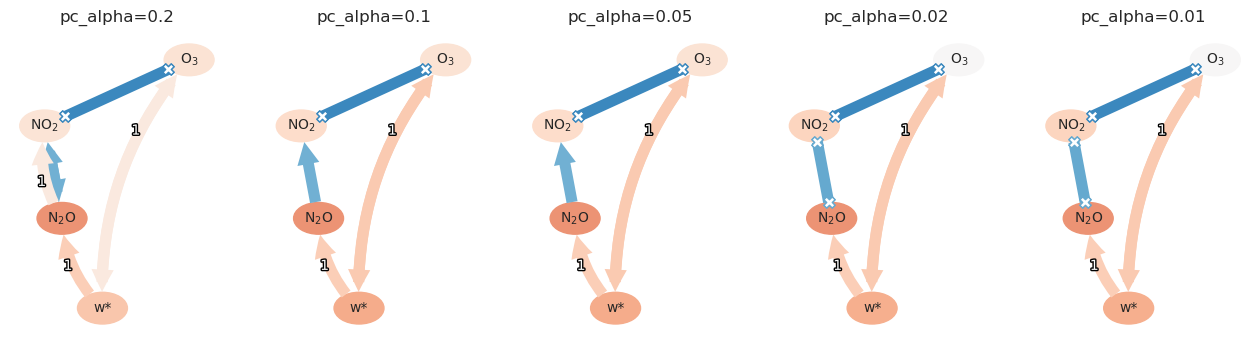

TOMCAT
fin vars ['w*', 'N$_2$O', 'NO$_2$', 'O$_3$']
Detrending timeseries in dataset TOMCAT
# Data Length   No of Vars
      199             4
Start regime: No_mask with 199 steps
Sensitivity tests: Calculating causal graphs for different pc_alpha
tau_max =  2


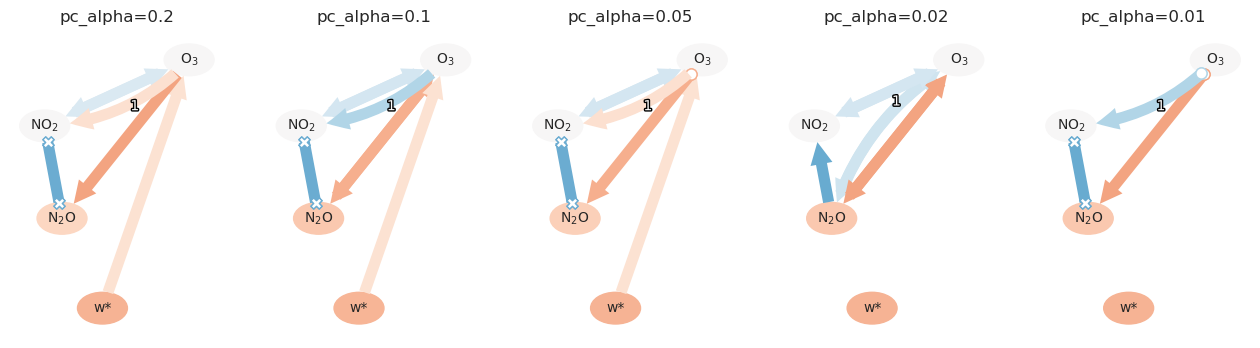

In [ ]:
link_assumptions = None
common_dict = {}
list_correlations = []
####################################
##########Settings##################
standardize_data           = True
#set save_fin_dict to True to save the dictionary with LPCMCI results into a file
save_fin_dict              = False

########################
# Define CI tests
parcorr = ParCorr(significance='analytic', mask_type='y')
Rparcorr = RobustParCorr(significance='analytic', mask_type='y')
##########################

for source in df_dict.keys():
    print(source)

    var_names_run = list(var_names)

    df_exp = df_dict[source]
    print ('fin vars', var_names_run)
    common_dict[source] = {}

    # --- Build data matrix ---
    data = np.zeros((len(year_fraction), len(var_names_run)))
    print("Detrending timeseries in dataset", source)
    for j, key in enumerate(var_names_run):
        data[:, j] =  detrending (df_exp[key])

    if standardize_data:
        data = scaler.fit_transform(data)

    T, N = data.shape
    print("# Data Length   No of Vars")
    print("     ", T, "           ", N)
    
    # --- Regimes are source-specific (OBS and TOMCAT)---
    for regime in regime_masks_dict[source].keys():
        common_dict[source][regime] = {}


        mask_1d = regime_masks_dict[source][regime]  
        steps_per_regime = np.count_nonzero(mask_1d == 0)
        print("Start regime:", regime, "with", steps_per_regime, "steps")
        print ("Sensitivity tests: Calculating causal graphs for different pc_alpha")

        # apply same mask to all variables
        data_mask = np.zeros(data.shape, dtype=int)
        for i in range(N):
            data_mask[:, i] = mask_1d 
            
        dataframe = pp.DataFrame(
            data,
            datatime=year_fraction,
            var_names=var_names_run,
            mask=data_mask,
            missing_flag=999.
        )
        common_dict[source][regime]["dataframe"] = dataframe

        pcmci = PCMCI(dataframe=dataframe, cond_ind_test=Rparcorr, verbosity=0)

        correlationsB = pcmci.run_bivci(tau_max=5, val_only=True)["val_matrix"]
        correlations_lagged = pcmci.get_lagged_dependencies(tau_max=5, val_only=True)["val_matrix"]

        list_correlations.append(correlationsB)
        
        common_dict[source][regime]["correlation_bi"] = correlationsB
        common_dict[source][regime]["correlation_lagged"] = correlations_lagged


        # First glance into LPCMCI results for different pc_alpha
        # add to the list below all values of tau_max that should be tested
        if Fig4 or Fig6 or Fig7:
            list_for_tau_max = [2]
        elif Fig5: 
            list_for_tau_max = [1,2,3,4,5]
        for tau_max in list_for_tau_max:
            print("tau_max = ", tau_max)
            tau_min = 0
            for it in [0]:
                
                Rresults02, Rresults01, Rresults005, Rresults002, Rresults001 = lpcmci_sensitivity(
                    dataframe, Rparcorr, var_names_run, tau_max, tau_min, it, link_assumptions
                )
            common_dict[source][regime][tau_max] = {}
            common_dict[source][regime][tau_max]["LPCMCI"] = {
                "0.2":  Rresults02,
                "0.1":  Rresults01,
                "0.05": Rresults005,
                "0.02": Rresults002,
                "0.01": Rresults001,
            }           
        
if save_fin_dict: 
    np.save(f'file.npy', common_dict)          

#### Lets have a brief look into original causal graphs from OBS and the TOMCAT CTM simulation

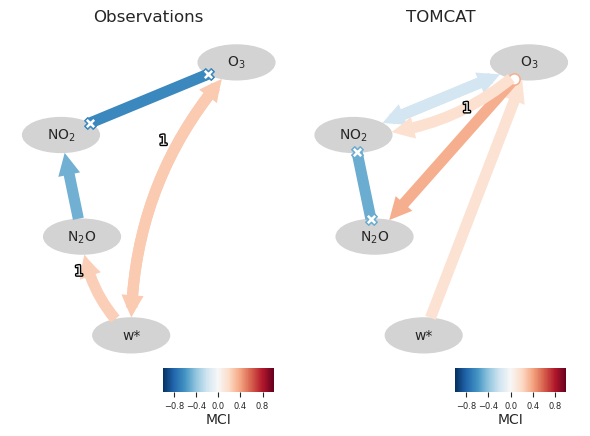

In [ ]:
#Plot original graphs from causal discovery
fig, axes = plt.subplots(1, 2, figsize=(6, 5))
regime = 'No_mask'

# --- OBS ---
tp.plot_graph(
    graph=common_dict['OBS'][regime][2]['LPCMCI']['0.05']['graph'],
    val_matrix= common_dict['OBS'][regime][2]['LPCMCI']['0.05']['val_matrix'],
    var_names=var_names,
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=True,
    cmap_nodes = None,
    fig_ax=(fig, axes[0]),
)
axes[0].set_title("Observations")


# --- TOMCAT ---
tp.plot_graph(
    graph=common_dict['TOMCAT'][regime][2]['LPCMCI']['0.05']['graph'],
    val_matrix=common_dict['TOMCAT'][regime][2]['LPCMCI']['0.05']['val_matrix'],
    var_names=var_names,
    node_pos=position_of_nodes(var_names),
    node_size=1.2,
    show_colorbar=True,
    cmap_nodes = None,
    fig_ax=(fig, axes[1]),
)
axes[1].set_title("TOMCAT")
# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust rect to make space for the colorbars
plt.show()


#### Now we interfere with the causal graph to achieve DAG based on the triangulation discussed in the manuscript

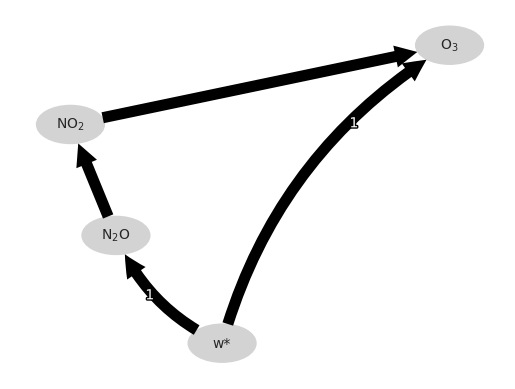

In [ ]:
# For causal effect estimation the algorithm requires DAG. 
graph_orig = common_dict['OBS']['No_mask'][2]['LPCMCI']['0.05']['graph']
# Graph fixes for core vars in QBO regimes
graph_orig [2][3][0] = '-->'
graph_orig [3][2][0] = '<--'
graph_orig [0][0][2] = '-->'
graph_orig [0][3][1] = '-->'
graph_list = []         
                    
if QBO_as_a_regime: # use the sane DAG for analyzed QBO regimes
    graph_list.extend(fix_graph(graph_orig) for _ in range(3))
else: 
    graph_list.append (graph_orig)
      
tp.plot_graph(
        graph=graph_orig,
        var_names=var_names,
        node_pos = position_of_nodes(var_names),
        node_size = 1.2,
        show_colorbar=False,
        )
plt.show()

# Figure 4

OBS
0 No_mask
Processing key: No_mask
Skipping due to overlap: Cause w* and Effect w*
Skipping due to overlap: Cause N$_2$O and Effect N$_2$O
Skipping due to overlap: Cause NO$_2$ and Effect NO$_2$
Skipping due to overlap: Cause O$_3$ and Effect O$_3$
Finished at: 2026-05-05 10:21:49
TOMCAT
0 No_mask
Processing key: No_mask
Skipping due to overlap: Cause w* and Effect w*
Skipping due to overlap: Cause N$_2$O and Effect N$_2$O
Skipping due to overlap: Cause NO$_2$ and Effect NO$_2$
Skipping due to overlap: Cause O$_3$ and Effect O$_3$
Finished at: 2026-05-05 10:28:07


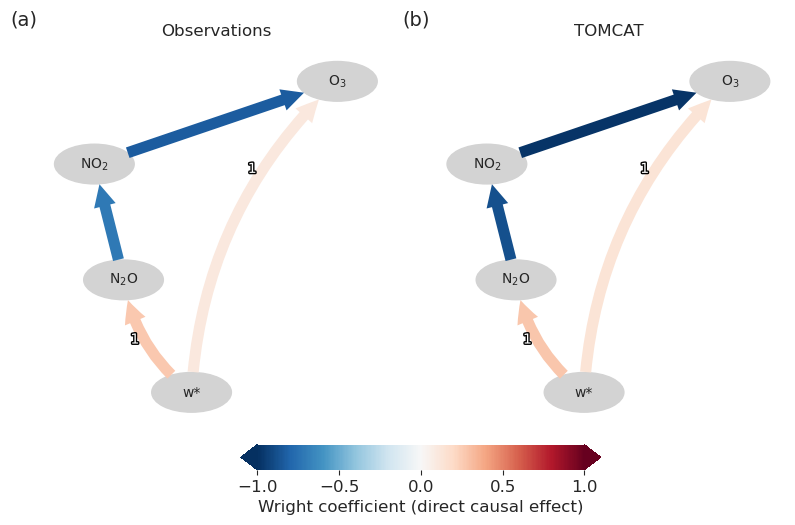

In [ ]:
if Fig4: 
    dict_ = {}
    for source in common_dict.keys():
        print (source)
        dict_[source] = {}
        
        all_results      = calculate_wright_coeffs (common_dict, source, graph_list = graph_list, var_names = var_names)
        val_matrix_list  = convert_dict_to_val_matrix (var_names, all_results, 'beta')
        dict_[source]['val_matrix'] = val_matrix_list
        dict_[source]['graph'] = graph_list
        print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    
    # Calculations are done. Time for plotting
    fig, axes = plt.subplots(1, 2, figsize=(8, 5))
    
    
    
    # --- OBS ---
    tp.plot_graph(
        graph=graph_orig,
        val_matrix=dict_['OBS']['val_matrix'][0],
        var_names=var_names,
        node_pos=position_of_nodes(var_names),
        node_size=1.2,
        show_colorbar=False,
        cmap_nodes = None,
        fig_ax=(fig, axes[0]),
    )
    axes[0].set_title("Observations")
    axes[0].text(-0.08, 1.05, '(a)',
                transform=axes[0].transAxes,
                fontsize=14)
    # --- TOMCAT ---
    tp.plot_graph(
        graph=graph_orig,
        val_matrix=dict_['TOMCAT']['val_matrix'][0],
        var_names=var_names,
        node_pos=position_of_nodes(var_names),
        node_size=1.2,
        show_colorbar=False,
        cmap_nodes = None,
        fig_ax=(fig, axes[1]),
    )

    axes[1].set_title("TOMCAT")
    axes[1].text(-0.08, 1.05, '(b)',
                transform=axes[1].transAxes,
                fontsize=14)

    vmin = -1
    vmax = 1
    # Add colorbars below the plots, one for edges and one for nodes
    cbar_ax_edges = fig.add_axes([0.3, 0.05, 0.45, 0.05])  # Position for edges colorbar

    # Set normalization for colorbars
    norm_edges = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # Create the colorbars with horizontal orientation
    cb_edges = mpl.colorbar.ColorbarBase(cbar_ax_edges, cmap='RdBu_r', norm=norm_edges, orientation='horizontal', extend='both')

    # Label colorbars
    fs = 12
    cb_edges.set_label(label=r'Wright coefficient (direct causal effect)', fontsize=fs)
    cb_edges.ax.tick_params(labelsize=fs)
    cb_edges.outline.set_visible(False)


    # Adjust layout for better spacing
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust rect to make space for the colorbars
    plt.show()
    # plt.savefig('fig.png', bbox_inches = 'tight', dpi = 300)


# Fig. 5 Sensitivity tests

In [ ]:
if Fig5: 
    experiment = 'OBS'
    # We care about these pairs only:
    target_ordered = [
        ("w*", "O$_3$"),
        ("w*", "N$_2$O"),
        ("N$_2$O", "NO$_2$"),
        ("NO$_2$", "O$_3$")
    ]

    result_keys = ["0.01", "0.02", "0.05", "0.1", "0.2"]
    markers = {"0.01": "o", "0.02": "d", "0.05": "^", "0.1": "X", "0.2": "8"}

    offsets = np.linspace(-0.3, 0.3, len(result_keys))  # horizontal spacing for markers
    vertical_jitter = 0.12  # small vertical offset for repeated points

    # y-axis labels (no bidirectional arrow)
    y_labels = [f"{a} – {b}" for (a, b) in target_ordered]
    link_map = {lab: i for i, lab in enumerate(y_labels)}

    # quick lookup: for any unordered pair, what is the "preferred" (forward) orientation?
    # e.g. frozenset({"NO2","O3"}) -> ("NO2","O3")
    preferred_dir = {frozenset((a, b)): (a, b) for (a, b) in target_ordered}


    def is_bidirectional_or_undirected(rel: str) -> bool:
        """
        Tigramite-like relation strings that mean 'bidirectional/undirected'.
        """
        rel = rel.strip()
        if rel in {"x--x", "o-o", "<->", "<-->", "x-x"}:
            return True

        # Generic heuristic: if there is NO arrowhead, treat as undirected-ish
        # (keeps 'x--x' style even if slightly different)
        has_arrow = (">" in rel) or ("<" in rel)
        if not has_arrow and rel != "":
            return True

        return False


    for mask_key in common_dict[experiment].keys():
        x_positions, y_positions, values_all, lags_all, result_sources = [], [], [], [], []
        exp_keys = sorted(k for k in common_dict[experiment][mask_key].keys() if isinstance(k, int))
        x_map = {k: i for i, k in enumerate(exp_keys)}

        # track how many times a (target link label) occurs per x position for vertical jitter
        link_count = defaultdict(lambda: defaultdict(int))

        for exp_key in exp_keys:
            for ri, rkey in enumerate(result_keys):

                if rkey not in common_dict[experiment][mask_key][exp_key]["LPCMCI"]:
                    continue

                graph = common_dict[experiment][mask_key][exp_key]["LPCMCI"][rkey]["graph"].copy()

                # optional normalization (doesn't affect selection logic)
                graph[graph == "o->"] = "-->"
                graph[graph == "<-o"] = "<--"

                val_matrix = common_dict[experiment][mask_key][exp_key]["LPCMCI"][rkey]["val_matrix"]
                variables = var_names
                n = len(variables)
                lags = graph.shape[-1]

                # prevent duplicates (esp. mirrored lag=0 or bidirectional encoded twice)
                # key includes exp_key position, "forward label", lag, rkey
                seen = set()

                for i in range(n):
                    for j in range(n):
                        for lag in range(lags):

                            rel = graph[i, j, lag]
                            if rel == "":
                                continue

                            a = variables[i]
                            b = variables[j]
                            pair = frozenset((a, b))

                            # only consider the 3 variable-pairs of interest
                            if pair not in preferred_dir:
                                continue

                            # preferred forward direction for this pair
                            src, tgt = preferred_dir[pair]

                            # Decide whether to accept this cell:
                            # - If it's already in forward orientation (src->tgt): accept any non-empty relation
                            # - If it's reverse (tgt->src): accept ONLY if the relation is bidirectional/undirected
                            accept = False
                            if a == src and b == tgt:
                                accept = True
                            elif a == tgt and b == src and is_bidirectional_or_undirected(rel):
                                accept = True

                            if not accept:
                                continue

                            val = val_matrix[i, j, lag]
                            if not np.isfinite(val):
                                continue

                            # y-axis label is ALWAYS the preferred forward direction
                            ylab = f"{src} – {tgt}"
                            key = (x_map[exp_key], ylab, lag, rkey)
                            if key in seen:
                                continue
                            seen.add(key)

                            # x position
                            x_positions.append(x_map[exp_key] + offsets[ri])

                            # y position with vertical jitter for repeated points at same x
                            count = link_count[ylab][x_map[exp_key]]
                            y_positions.append(link_map[ylab] + vertical_jitter * count)
                            link_count[ylab][x_map[exp_key]] += 1

                            values_all.append(val)
                            lags_all.append(lag)
                            result_sources.append(rkey)

        if len(x_positions) == 0:
            continue

        plt.figure(figsize=(16, 6))
        sc = None

        for rkey in result_keys:
            idx = [ii for ii, rr in enumerate(result_sources) if rr == rkey]
            if len(idx) == 0:
                continue

            sc = plt.scatter(
                [x_positions[ii] for ii in idx],
                [y_positions[ii] for ii in idx],
                c=[values_all[ii] for ii in idx],
                cmap="RdBu_r",
                s=400,
                edgecolor="k",
                vmin=-0.8,
                vmax=0.8,
                marker=markers[rkey],
                label=rkey,
            )

            # lag text inside markers
            for ii in idx:
                plt.text(
                    x_positions[ii],
                    y_positions[ii],
                    str(lags_all[ii]),
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="black",
                )

        plt.xlabel("$tau_{max}$", fontsize=14)
        plt.ylabel("Links", fontsize=14)

        cbar = plt.colorbar(sc, label="Link strength")
        cbar.ax.yaxis.set_label_position("left")
        cbar.ax.yaxis.label.set_size(14)
        cbar.ax.tick_params(labelsize=12)

        # vertical lines at each exp_key (tau_max)
        for k in exp_keys:
            plt.axvline(x_map[k], color="gray", linestyle="--", alpha=0.4, linewidth=1)

        # legend with proxy handles
        proxy_handles = []
        for rkey, marker in markers.items():
            proxy_handles.append(
                plt.Line2D(
                    [],
                    [],
                    marker=marker,
                    color="black",
                    markerfacecolor="none",
                    markersize=15,
                    linestyle="None",
                )
            )

        plt.legend(
            handles=proxy_handles,
            labels=result_keys,
            title="Result set $alpha_{pc}$",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            ncol=len(result_keys),
            frameon=False,
            title_fontsize=14,
            fontsize=12,
        )

        plt.yticks(list(link_map.values()), y_labels, fontsize=14)
        plt.xticks([x_map[k] for k in exp_keys], [str(k) for k in exp_keys], fontsize=14)
        plt.xlim(-1, len(exp_keys))

        plt.tight_layout()
        # plt.show()

        plt.savefig("fig.png", bbox_inches="tight", dpi=300)

# Figure 6. Regime-oriented comparison

In [ ]:
if Fig6:
    # =========================================================
    # CALCULATING PATH COEFFICIENTS FOR EACH DATASOURCE
    # =========================================================
    
    print("Started at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S")) 
    dict_ = {}
    for source in common_dict.keys():
        print (source)
        dict_[source] = {}
        all_results      = calculate_wright_coeffs (common_dict, source, graph_list = graph_list, var_names = var_names)
        val_matrix_list  = convert_dict_to_val_matrix (var_names, all_results, 'beta')
        dict_[source]['val_matrix'] = val_matrix_list
        dict_[source]['graph'] = graph_list
    print("Finished at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))    
        
    # =========================================================
    # PLOTTING
    # =========================================================

    # Regime labels in the same order as reg = 0, 1, 2
    regimes = ["Full period", "Easterlies", "Westerlies"]

    # Dataset names used in the plot -> keys in dict_
    dataset_map = {
        "Observations": "OBS",
       "TOMCAT": "TOMCAT",
    }

    datasets = ["Observations", "TOMCAT"]

    # ---------------------------------------------------------
    # Links in the exact order we want them to appear in plot
    # ---------------------------------------------------------
    link_specs = [
        {
            "plot_label": r"$w^\ast \rightarrow \mathrm{O_3}$ (lag 1)",
            "source": "w*",
            "target": "O$_3$",
            "lag": 1,
        },
        {
            "plot_label": r"$\mathrm{NO_2} \rightarrow \mathrm{O_3}$ (lag 0)",
            "source": "NO$_2$",
            "target": "O$_3$",
            "lag": 0,
        },
        {
            "plot_label": r"$\mathrm{N_2O} \rightarrow \mathrm{NO_2}$ (lag 0)",
            "source": "N$_2$O",
            "target": "NO$_2$",
            "lag": 0,
        },
        {
            "plot_label": r"$w^\ast \rightarrow \mathrm{N_2O}$ (lag 1)",
            "source": "w*",
            "target": "N$_2$O",
            "lag": 1,
        },
    ]

    # Labels on the y-axis
    links = [item["plot_label"] for item in link_specs]

    # ---------------------------------------------------------
    # Create a lookup from variable name to matrix index
    # ---------------------------------------------------------
    name_to_idx = {name: idx for idx, name in enumerate(var_names)}

    # Assuming:
    # l = 0  -> lag 0
    # l = 1  -> lag 1
    # l = 2  -> lag 2
    lag_to_l_index = {
        0: 0,
        1: 1,
        2: 2,
    }

    # ---------------------------------------------------------
    # Build the data dictionary automatically
    # ---------------------------------------------------------
    data = {}

    for plot_dataset, dict_key in dataset_map.items():
        for reg_idx, reg_name in enumerate(regimes):
            vals = []

            for spec in link_specs:
                i = name_to_idx[spec["source"]]
                j = name_to_idx[spec["target"]]
                l = lag_to_l_index[spec["lag"]]

                # Optional safety check:
                if graph_orig[i, j, l] != '-->':
                    print(
                        f"Warning: expected link not found in graph_orig: "
                        f"{spec['source']} -{spec['lag']}-> {spec['target']}"
                    )

                val = dict_[dict_key]['val_matrix'][reg_idx][i, j, l]
                vals.append(float(val))

            data[(plot_dataset, reg_name)] = vals

    # ---------------------------------------------------------
    # Double-check: print extracted values for checking
    # ---------------------------------------------------------
    print("\nAutomatically extracted values:")
    for key, vals in data.items():
        print(key, [f"{v:.2f}" for v in vals])

    # =========================================================
    # PLOT IS HERE
    # =========================================================

    plt.rcParams.update({
        "figure.dpi": 170,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    y = np.arange(len(links))
    bar_h = 0.22
    xmin, xmax = -1.05, 0.35

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)

    for ax, ds in zip(axes, datasets):
        for i, reg in enumerate(regimes):
            vals = np.array(data[(ds, reg)])
            ax.barh(y + (i - 1) * bar_h, vals, height=bar_h, label=reg)

        ax.axvline(0, linewidth=1, linestyle="--", color="gray")
        ax.set_title(ds)
        ax.set_xlim(xmin, xmax)
        ax.set_yticks(y)
        ax.set_yticklabels(links)
        ax.set_xlabel("Wright coefficient")
        ax.grid(True, axis="x", alpha=0.3)

    # Panel labels
    axes[0].text(
        -0.12, 1.05, "(a)",
        transform=axes[0].transAxes,
        fontsize=12,
        va="top"
    )

    axes[1].text(
        -0.12, 1.05, "(b)",
        transform=axes[1].transAxes,
        fontsize=12,
        va="top"
    )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.09)
    )

    fig.tight_layout()

    plt.show()

    # fig.savefig("fig.png",  bbox_inches="tight",  dpi=300)

# Figure 7. Total causal effects across time lags

In [ ]:
#Please, run the code below for different set of list_x and list_y. 
if Fig7: 
    
    masks = list(common_dict['OBS'].keys())
    all_results_list= []
    dict_test = {}
    for mask in masks: 
        print (mask)
        dict_test [mask] = {}
        for source in common_dict.keys(): 
            print (source)
            dataframe = common_dict[source][mask]['dataframe']
            all_results = temporal_evolution(dataframe, graph_orig, 
                                                list_x = [0], 
                                                list_y = [1,2,3], 
                                                tau_max = 6, 
                                                mediator = None,
                                                
                                                        )
            dict_test [mask][source] = all_results
            all_results_list.append (all_results)
    plot_temporal_evolution (dict_test, var_names, None, False)